## dataset source 
the dataset was downloaded from  kaggle and contains information about crossfit competition including demographic characteristic, status, overall score overall rank, country, region and affiliate information.
the dataset can be used to explore the charcteristics of crossfit competitors and identify patterns and relationship between competitor attributes and competition results.

In [16]:
import pandas as pd


In [17]:
crossfit_df = pd.read_csv("df_games_conso.csv")

In [190]:
crossfit_df.shape


(1714, 22)

In [191]:
crossfit_df.columns

Index(['competitorId', 'competitorName', 'firstName', 'lastName', 'status',
       'gender', 'countryOfOriginCode', 'countryOfOriginName', 'regionId',
       'regionName', 'affiliateId', 'affiliateName', 'age', 'height', 'weight',
       'overallRank', 'overallScore', 'genderId', 'year', 'weight_kg',
       'height_cm', 'age_group'],
      dtype='str')

In [33]:
crossfit_df.head()

,competitorId,competitorName,firstName,lastName,status,gender,countryOfOriginCode,countryOfOriginName,regionId,regionName,affiliateId,affiliateName,age,height,weight,overallRank,overallScore,genderId,year
0,164070,James Fitzgerald,James,Fitzgerald,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,33,69 in,176 lb,1,272,1,2007
1,57785,Brett Marshall,Brett,Marshall,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,33,168 cm,155 lb,2,270,1,2007
2,10091,Josh Everett,Josh,Everett,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,32,69 in,185 lb,3,267,1,2007
3,27065,Chris Spealler,Chris,Spealler,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,28,65 in,143 lb,4,261,1,2007
4,7173,Breck Berry,Breck,Berry,ACT,M,NaN,NaN,NaN,NaN,NaN,NaN,31,67 in,170 lb,5,252,1,2007


## data structure 

In [34]:
crossfit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1714 entries, 0 to 1713
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   competitorId         1714 non-null   int64  
 1   competitorName       1714 non-null   str    
 2   firstName            1714 non-null   str    
 3   lastName             1713 non-null   str    
 4   status               1714 non-null   str    
 5   gender               1714 non-null   str    
 6   countryOfOriginCode  990 non-null    str    
 7   countryOfOriginName  978 non-null    str    
 8   regionId             828 non-null    float64
 9   regionName           828 non-null    str    
 10  affiliateId          912 non-null    float64
 11  affiliateName        912 non-null    str    
 12  age                  1714 non-null   int64  
 13  height               1545 non-null   str    
 14  weight               1550 non-null   str    
 15  overallRank          1714 non-null   str    
 16 

## selected variables for initial inspection

In [35]:

crossfit_df[["age" , "height" , "weight" , "overallRank" , "overallScore"]]

,age,height,weight,overallRank,overallScore
0,33,69 in,176 lb,1,272
1,33,168 cm,155 lb,2,270
2,32,69 in,185 lb,3,267
3,28,65 in,143 lb,4,261
4,31,67 in,170 lb,5,252
...,...,...,...,...,...
1709,19,64 in,140 lb,0,0
1710,18,65 in,140 lb,0,0
1711,27,157 cm,60 kg,0,0
1712,24,169 cm,70 kg,0,0


## missing values

In [20]:
crossfit_df.isnull().sum()

competitorId             0
competitorName           0
firstName                0
lastName                 1
status                   0
gender                   0
countryOfOriginCode    724
countryOfOriginName    736
regionId               886
regionName             886
affiliateId            802
affiliateName          802
age                      0
height                 169
weight                 164
overallRank              0
overallScore             0
genderId                 0
year                     0
dtype: int64

## unique values

In [21]:

crossfit_df.nunique()

competitorId           953
competitorName         975
firstName              639
lastName               864
status                   5
gender                   2
countryOfOriginCode    114
countryOfOriginName    113
regionId                34
regionName              29
affiliateId            465
affiliateName          470
age                     35
height                  67
weight                 143
overallRank            143
overallScore           832
genderId                 2
year                    17
dtype: int64

## duplicate Analysis
no fulli duplicated rows were found. some competitor IDs appear multiple times because the same athlete participated in different competition years. these records are valid and were kept in the dataset

In [22]:
crossfit_df.duplicated().sum()

np.int64(0)

In [23]:
duplicate_competitors = crossfit_df[crossfit_df.duplicated(subset=["competitorId"], keep=False)]
duplicate_competitors = duplicate_competitors.sort_values(["competitorId", "year"])
duplicate_competitors[["competitorId" , "competitorName" , "year" , "overallRank", "overallScore"]].head(20)

,competitorId,competitorName,year,overallRank,overallScore
10,1616,Russ Greene,2007,11,232
116,1616,Russ Greene,2008,53,21:30
761,1690,Travis Mayer,2014,29,483
908,1690,Travis Mayer,2016,10,702
991,1690,Travis Mayer,2017,12,674
1149,1690,Travis Mayer,2019,12,368
1431,1690,Travis Mayer,2020,19,0
1484,1690,Travis Mayer,2021,12,822
1570,1690,Travis Mayer,2022,18,685
576,1819,Justin Allen,2012,26,397


## suspicious values

In [28]:
# number of suspicious rows
len(zero_values)

274

# display a sample of suspocious rows

In [27]:
zero_values = crossfit_df[(crossfit_df["overallRank"] == "0") | (crossfit_df["overallScore"] == "0")]
zero_values[["competitorName" , "status" , "year" , "overallRank" , "overallScore"]].head(20)                                                                  

,competitorName,status,year,overallRank,overallScore
363,Lee Knight,CUT,2009,71,0
364,Joy Nguyen,CUT,2009,71,0
451,Sam Ryder,CUT,2010,42,0
452,Elanna Robson,CUT,2010,43,0
453,Diago Johana,CUT,2010,44,0
454,Magnúsdóttir Jenny,CUT,2010,45,0
596,Orlando Trejo,WD,2012,46,0
640,Denae Brown,WD,2012,44,0
641,Allison King,WD,2012,44,0
688,Mikko Salo,ACT,2013,0,0


In [31]:
# status distribution among suspicious rows
zero_values["status"].value_counts()

status
ACT    139
CUT    127
WD       6
DQ       2
Name: count, dtype: int64

In [32]:
# percentage of each status among suspicious rows
zero_values["status"].value_counts(normalize=True) * 100

status
ACT    50.729927
CUT    46.350365
WD      2.189781
DQ      0.729927
Name: proportion, dtype: float64

##suspicious values analysis
a total of 274 records contain a zero value in either 'overallRank' or 'overallScore'.
among these records, 50.73% have status 'act', 46.35% have status 'CUT', 2.19% have status 'WD' and
0.73% have status 'DQ'. 
the zero values are therfore not associated with only one competition status. they may contain meaningful competition information rather than simply representing missing or incorrect data. furthe investigation is required before deciding ehther these values should be removed or replaced.

In [37]:
zero_values["year"].value_counts().sort_index()

year
2009      2
2010      4
2012      3
2013      1
2014      1
2015      1
2018      1
2019    124
2020     50
2021      6
2023     81
Name: count, dtype: int64

In [39]:
pd.crosstab(zero_values["year"], zero_values["status"])

status,ACT,CUT,DQ,WD
year,,,,
2009,0,2,0,0
2010,0,4,0,0
2012,0,0,0,3
2013,1,0,0,0
2014,1,0,0,0
2015,1,0,0,0
2018,1,0,0,0
2019,0,121,2,1
2020,49,0,0,1


## suspicious zero values analysis
the zero values in overallRank and overallScore were examined by year and competition status.
the results show that these zero values are not randomaly distributed, in 2019 most of the suspicious records had the status cut, while in 2020 and 2023 most of them had the status ACT. this suggests that zero values may be related to the way competition results were recorded in specific years, rather than simply representing missing or incorrect data.
therefore the zero values will not be removed or replaced.

In [40]:
crossfit_df[["age", "height", "weight", "overallRank", "overallScore"]].describe()

,age
count,1714.000000
mean,26.628938
std,7.337817
min,0.000000
25%,24.000000
50%,27.000000
75%,30.000000
max,54.000000


In [42]:
# we need to convert the height weight overallRank and overallScore because they stored as strings
cols_to_convert = ["height" , "weight", "overallRank", "overallScore"]
for col in cols_to_convert:
    crossfit_df[col] = pd.to_numeric(crossfit_df[col], errors="coerce")

In [43]:
crossfit_df[["age", "height", "weight", "overallRank", "overallScore"]].describe()

,age,height,weight,overallRank,overallScore
count,1714.000000,0.0,0.0,1708.000000,1559.000000
mean,26.628938,NaN,NaN,31.426815,339.803079
std,7.337817,NaN,NaN,29.181189,297.453586
min,0.000000,NaN,NaN,0.000000,0.000000
25%,24.000000,NaN,NaN,11.000000,91.000000
50%,27.000000,NaN,NaN,24.500000,257.000000
75%,30.000000,NaN,NaN,39.000000,578.500000
max,54.000000,NaN,NaN,141.000000,1435.000000


In [45]:
original_df = pd.read_csv("df_games_conso.csv")

In [46]:
original_df[["height", "weight"]].head(10)

,height,weight
0,69 in,176 lb
1,168 cm,155 lb
2,69 in,185 lb
3,65 in,143 lb
4,67 in,170 lb
5,NaN,205 lb
6,72 in,185 lb
7,NaN,NaN
8,NaN,NaN
9,71 in,193 lb


In [49]:
crossfit_df["weight_kg"] = ( original_df["weight"].astype("string").str.replace(" lb" , "", regex=False))
crossfit_df["weight_kg"] = pd.to_numeric(crossfit_df["weight_kg"],errors="coerce") * 0.453592

In [50]:
crossfit_df[["weight",  "weight_kg"]].head(10)

,weight,weight_kg
0,NaN,79.832192
1,NaN,70.30676
2,NaN,83.91452
3,NaN,64.863656
4,NaN,77.11064
5,NaN,92.98636
6,NaN,83.91452
7,NaN,<NA>
8,NaN,<NA>
9,NaN,87.543256


In [55]:
def convert_height(value):
    if pd.isna(value):
        return None
    value = str(value)
    if "cm" in value:
        return float(value.replace(" cm", ""))
    elif "in" in value:
        return float(value.replace(" in", "")) * 2.54
    return None

In [56]:
convert_height(original_df["height"].iloc[0])

175.26

In [57]:
crossfit_df["height_cm"] = original_df["height"].apply(convert_height)

In [59]:
pd.DataFrame({"height_original": original_df["height"], "height_cm": crossfit_df["height_cm"]}).head(10)

,height_original,height_cm
0,69 in,175.26
1,168 cm,168.00
2,69 in,175.26
3,65 in,165.10
4,67 in,170.18
5,NaN,NaN
6,72 in,182.88
7,NaN,NaN
8,NaN,NaN
9,71 in,180.34


In [60]:
crossfit_df[["age", "height_cm", "weight_kg", "overallRank", "overallScore"]].describe()

,age,height_cm,weight_kg,overallRank,overallScore
count,1714.000000,1545.000000,1218.0,1708.000000,1559.000000
mean,26.628938,171.288867,77.786559,31.426815,339.803079
std,7.337817,33.283336,13.445774,29.181189,297.453586
min,0.000000,1.000000,24.94756,0.000000,0.000000
25%,24.000000,165.100000,65.77084,11.000000,91.000000
50%,27.000000,171.000000,79.3786,24.500000,257.000000
75%,30.000000,177.800000,88.45044,39.000000,578.500000
max,54.000000,1297.940000,120.20188,141.000000,1435.000000


In [62]:
crossfit_df[(crossfit_df["height_cm"] < 140) | (crossfit_df["height_cm"] > 220)][["competitorName", "height_cm"]]

,competitorName,height_cm
36,Brandon Banks,20.32
100,Brandon Banks,20.32
285,Angel Orozco,1297.94
445,Alicia Connors,63.00
538,Alicia Connors,63.00
659,Travis Mayer,15.24
772,Emmanuel Maldonado,12.70
1131,Brenda Castro,2.00
1202,Shingo Moromasa,12.70
1221,Alvaro Lopez,15.24


## height data qualiity
the height_cm column contains several unrealistic values, such as extremely low or extremely hight heights. these values are likely caused by inconsistent height formats in the original dataset.

In [63]:
crossfit_df["age"].describe()

count    1714.000000
mean       26.628938
std         7.337817
min         0.000000
25%        24.000000
50%        27.000000
75%        30.000000
max        54.000000
Name: age, dtype: float64

In [64]:
crossfit_df[crossfit_df["age"] == 0][["competitorName", "age"]]

,competitorName,age
7,Evan Von,0
8,Brent Oakson,0
15,John Murphy,0
16,Ryan Wolley,0
21,Andreas De,0
...,...,...
364,Joy Nguyen,0
405,Erik Szakaly,0
440,Jessica Sharratt,0
452,Elanna Robson,0


## suspicious age values
the age column contains 77 records with an age value of 0. since an age value is not realistic for crossfit competitors these values are considered invailed or placeholder values. they will be excluded from analysis involving age.

In [65]:
crossfit_df.nunique()

competitorId           953
competitorName         975
firstName              639
lastName               864
status                   5
gender                   2
countryOfOriginCode    114
countryOfOriginName    113
regionId                34
regionName              29
affiliateId            465
affiliateName          470
age                     35
height                   0
weight                   0
overallRank            142
overallScore           693
genderId                 2
year                    17
weight_kg               97
height_cm               67
dtype: int64

## cardinality analysis 
the number of unique values was. examined for each column categorical variables such as gender and status have low cardinality while variables such a competitor name, country and overallScore have hiher cardinality the dataset contains 1741 rows but 953 unique copetitor IDs, indicating that some competitorsb appear more than once in dataset.

In [67]:
crossfit_df["gender"].value_counts()

gender
M    921
F    793
Name: count, dtype: int64

In [66]:
crossfit_df["gender"].value_counts(normalize = True) * 100

gender
M    53.733956
F    46.266044
Name: proportion, dtype: float64

In [70]:
import sys 
!{sys.executable} -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 20.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [71]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


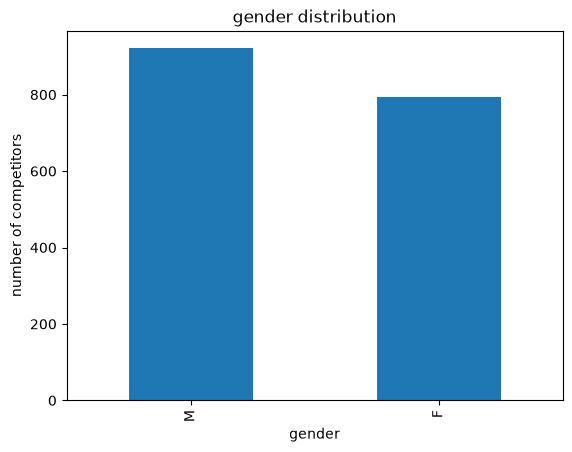

In [74]:
crossfit_df["gender"].value_counts().plot(kind="bar")
plt.title("gender distribution")
plt.xlabel("gender")
plt.ylabel("number of competitors")
plt.show()

In [75]:
crossfit_df[crossfit_df["age"] > 0]["age"].describe()

count    1637.000000
mean       27.881491
std         4.629620
min        13.000000
25%        25.000000
50%        28.000000
75%        30.000000
max        54.000000
Name: age, dtype: float64

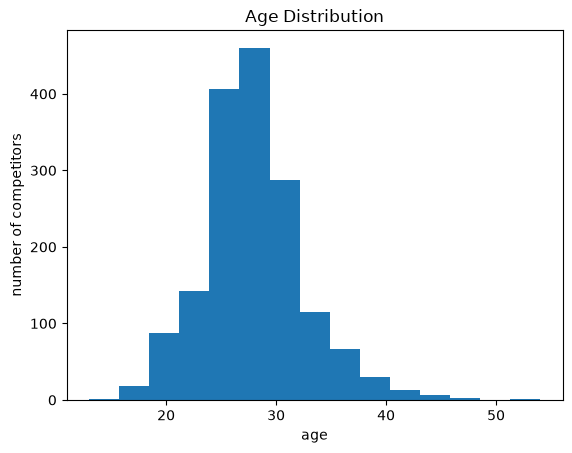

In [78]:
crossfit_df[crossfit_df["age"] > 0]["age"].plot(kind="hist", bins=15)
plt.title("Age Distribution")
plt.xlabel("age")
plt.ylabel("number of competitors")
plt.show()

## Age distribution 
most competitors are in their mid to late twenties, with the majority of age concetrated approximately
netween 23 and 32 the distribution shows fewer competitorsat older age

In [85]:
age_valide = crossfit_df[crossfit_df["age"] > 0]["age"]
Q1 = age_valide.quantile(0.25)
Q3 = age_valide.quantile(0.75)
IQR = Q3 - Q1
Q1, Q3, IQR

(np.float64(25.0), np.float64(30.0), np.float64(5.0))

In [86]:
age_valide.skew()

np.float64(0.6844072580124432)

## Age skewness
the skewness of the ege distribution is approximatly  0.68 indicating a moderate positive skew this means that most competitors are concetrated around younger ages while a smaller number of older competitors extend the distribution to the right

In [87]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound, upper_bound

(np.float64(17.5), np.float64(37.5))

In [93]:
age_valid = crossfit_df[crossfit_df["age"] > 0]["age"]
age_outliers = age_valid[(age_valid < lower_bound) | (age_valid > upper_bound)]
age_outliers.sort_values()

43      13
22      16
58      16
31      16
636     16
        ..
430     45
1242    46
23      46
343     47
29      54
Name: age, Length: 66, dtype: int64

In [94]:
age_outliers.value_counts().sort_index()

age
13     1
16     4
17     7
38    12
39    10
40     8
41     3
42     6
43     4
44     5
45     2
46     2
47     1
54     1
Name: count, dtype: int64

the IQR method identified 66 age values as outliers, with ages below 17.5 or above 37.5 most of these values, especially ages between 38 and 54 are reasonable and represent less common older competitors rather than data erros. therfore they will not be removed 
the age of 13 is unusually low compared to the rest of the dataset and should be considered a suspicious value that may require further verification

In [107]:
age_mean = age_valid.mean()
age_std = age_valid.std()
age_z = (age_valid - age_mean) / age_std
age_z_outliers = age_valid[age_z.abs() > 3]
age_z_outliers.sort_values()

43      13
12      42
48      42
209     42
280     42
205     42
501     42
108     43
132     43
88      43
1396    43
115     44
218     44
1397    44
160     44
17      44
38      45
430     45
1242    46
23      46
343     47
29      54
Name: age, dtype: int64

In [108]:
age_median = age_valid.median()
age_mad = (age_valid - age_median).abs().median()
modified_z = 0.6745 * (age_valid - age_median) / age_mad
age_mad_outliers = age_valid[modified_z.abs() > 3.5]
age_mad_outliers.sort_values()

17      44
218     44
160     44
115     44
1397    44
38      45
430     45
23      46
1242    46
343     47
29      54
Name: age, dtype: int64

three different methods were used todetect outliers in the age veriable : IQR, z-score and MAD
the methods do not identify exactly the same observations because they are based on different measures of central tendency and dispresion

In [95]:
crossfit_df["overallRank"].head(10)

0     1.0
1     2.0
2     3.0
3     4.0
4     5.0
5     6.0
6     7.0
7     8.0
8     9.0
9    10.0
Name: overallRank, dtype: float64

In [96]:
crossfit_df["overallRank"].describe()

count    1708.000000
mean       31.426815
std        29.181189
min         0.000000
25%        11.000000
50%        24.500000
75%        39.000000
max       141.000000
Name: overallRank, dtype: float64

In [97]:
(crossfit_df["overallRank"] == 0).sum()

np.int64(90)

In [100]:
rank_valid = crossfit_df[crossfit_df["overallRank"] > 0]["overallRank"]
rank_valid.describe()

count    1618.000000
mean       33.174907
std        28.998427
min         1.000000
25%        13.000000
50%        26.000000
75%        40.000000
max       141.000000
Name: overallRank, dtype: float64

In [101]:
Q1_rank = rank_valid.quantile(0.25)
Q3_rank = rank_valid.quantile(0.75)
IQR_rank = Q3_rank - Q1_rank
Q1_rank, Q3_rank, IQR_rank

(np.float64(13.0), np.float64(40.0), np.float64(27.0))

In [105]:
lower_rank = Q1_rank - 1.5 * IQR_rank
upper_rank = Q3_rank + 1.5 * IQR_rank
lower_rank, upper_rank

(np.float64(-27.5), np.float64(80.5))

In [106]:
rank_outliers = rank_valid[(rank_valid < lower_rank) | (rank_valid > upper_rank)]
rank_outliers.sort_values()

144      81.0
1219     81.0
1364     81.0
1220     82.0
1365     82.0
        ...  
1277    137.0
1278    138.0
1279    139.0
1280    140.0
1281    141.0
Name: overallRank, Length: 149, dtype: float64

In [113]:
rank_mean = rank_valid.mean()
rank_std = rank_valid.std()
rank_z = (rank_valid - rank_mean) / rank_std
rank_z_outliers = rank_valid[rank_z.abs() > 3]
rank_z_outliers.sort_values()

1260    121.0
1404    121.0
1405    122.0
1261    122.0
1262    123.0
1406    123.0
1407    124.0
1264    124.0
1265    125.0
1408    125.0
1409    126.0
1266    126.0
1267    127.0
1410    127.0
1411    128.0
1268    128.0
1412    129.0
1269    129.0
1270    130.0
1271    131.0
1272    132.0
1273    133.0
1274    134.0
1275    135.0
1276    136.0
1277    137.0
1278    138.0
1279    139.0
1280    140.0
1281    141.0
Name: overallRank, dtype: float64

In [114]:
rank_median = rank_valid.median()
rank_mad =(rank_valid - rank_median).abs().median()
rank_modified_z = 0.6745 * (rank_valid - rank_median) / rank_mad
rank_mad_outliers = rank_valid[rank_modified_z.abs() > 3.5]
rank_mad_outliers.sort_values()

157      94.0
1233     94.0
1377     94.0
1234     95.0
1378     95.0
        ...  
1277    137.0
1278    138.0
1279    139.0
1280    140.0
1281    141.0
Name: overallRank, Length: 110, dtype: float64

the three methods identified different numbers of outliers. IQR was most sensetive these values are not necessarily errors but observations in the distribution

In [115]:
rank_valid.skew()

np.float64(1.5773724926543031)

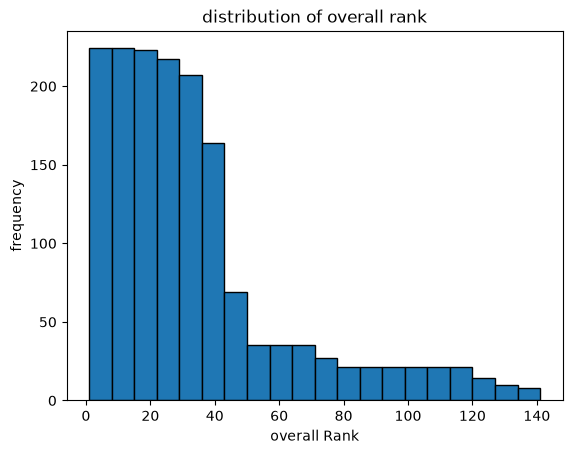

In [119]:
import matplotlib.pyplot as plt
plt.hist(rank_valid, bins=20, edgecolor="black")
plt.xlabel("overall Rank")
plt.ylabel("frequency")
plt.title("distribution of overall rank")
plt.show()

# the overall 5ank distribution is positively skewed 

In [120]:
crossfit_df["overallScore"].head(10)

0    272.0
1    270.0
2    267.0
3    261.0
4    252.0
5    248.0
6    243.0
7    239.0
8    235.0
9    232.0
Name: overallScore, dtype: float64

In [121]:
crossfit_df["overallScore"].describe()

count    1559.000000
mean      339.803079
std       297.453586
min         0.000000
25%        91.000000
50%       257.000000
75%       578.500000
max      1435.000000
Name: overallScore, dtype: float64

In [123]:
(crossfit_df["overallScore"] == 0).sum()

np.int64(274)

In [125]:
score_valid = crossfit_df[crossfit_df["overallScore"] >0]["overallScore"]
score_valid.describe()

count    1285.000000
mean      412.259144
std       278.326520
min         3.000000
25%       164.000000
50%       368.000000
75%       629.000000
max      1435.000000
Name: overallScore, dtype: float64

In [127]:
Q1_score = score_valid.quantile(0.25)
Q3_score = score_valid.quantile(0.75)
IQR_score = Q3_score -Q1_score
Q1_score, Q3_score, IQR_score

(np.float64(164.0), np.float64(629.0), np.float64(465.0))

In [131]:
lower_score = Q1_score - 1.5 * IQR_score
upper_score = Q3_score + 1.5 * IQR_score
lower_score, upper_score

(np.float64(-533.5), np.float64(1326.5))

In [133]:
score_outliers = score_valid[(score_valid < lower_score) | (score_valid > upper_score)]
score_outliers.sort_values()

1513    1435.0
Name: overallScore, dtype: float64

In [134]:
score_mean = score_valid.mean()
score_std = score_valid.std()
score_z = (score_valid - score_mean) / score_std
score_z_outliers = score_valid[score_z.abs() > 3]
score_z_outliers.sort_values()

1513    1435.0
Name: overallScore, dtype: float64

In [135]:
score_median = score_valid.median()
score_mad =(score_valid - score_median).abs().median()
score_modified_z = 0.6745 * (score_valid - score_median) / score_mad
score_mad_outliers = score_valid[score_modified_z.abs() > 3.5]
score_mad_outliers.sort_values()

Series([], Name: overallScore, dtype: float64)

In [136]:
score_valid.skew()

np.float64(0.5226172508657114)

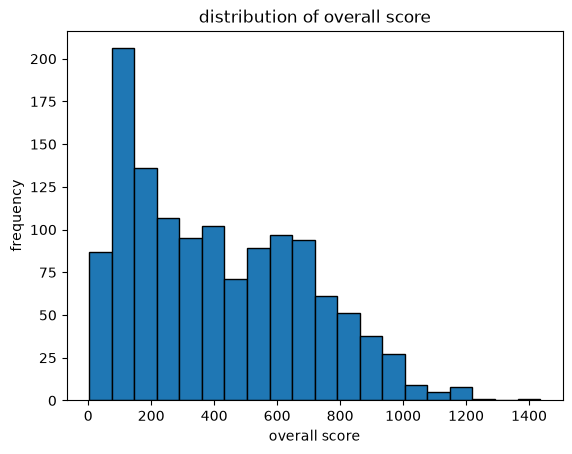

In [137]:
import matplotlib.pyplot as plt
plt.hist(score_valid, bins=20, edgecolor="black")
plt.xlabel("overall score")
plt.ylabel("frequency")
plt.title("distribution of overall score")
plt.show()

the overallscore di=stribution is moderatly positively skewed. most scores are concertrated at lower and middle values with a longer tail toward higher scores

In [138]:
crossfit_df.select_dtypes(include="number").columns

Index(['competitorId', 'regionId', 'affiliateId', 'age', 'height', 'weight',
       'overallRank', 'overallScore', 'genderId', 'year', 'weight_kg',
       'height_cm'],
      dtype='str')

In [139]:
crossfit_df["gender"].value_counts()

gender
M    921
F    793
Name: count, dtype: int64

In [141]:
crossfit_df["gender"].value_counts(normalize=True) *100

gender
M    53.733956
F    46.266044
Name: proportion, dtype: float64

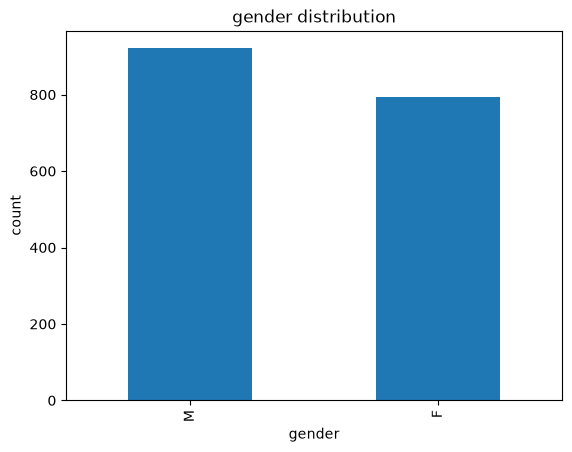

In [142]:
crossfit_df["gender"].value_counts().plot(kind="bar")
plt.xlabel("gender")
plt.ylabel("count")
plt.title("gender distribution")
plt.show()

the dataset is relatively balanced by gender, with approximately 53.7% male competitors and 46.3 female competitors

In [143]:
crossfit_df["countryOfOriginName"].value_counts()

countryOfOriginName
United States           438
Canada                   82
Australia                71
Iceland                  39
Finland                  17
                       ... 
Suriname                  1
Syrian Arab Republic      1
Brunei Darussalam         1
Samoa                     1
Mauritius                 1
Name: count, Length: 113, dtype: int64

In [144]:
(crossfit_df["countryOfOriginName"] == "israel").sum()

np.int64(0)

In [145]:
crossfit_df["countryOfOriginName"].nunique(), crossfit_df["countryOfOriginName"].isna().sum()

(113, np.int64(736))

In [147]:
crossfit_df["countryOfOriginName"].isna().mean()*100

np.float64(42.94049008168028)

In [148]:
country_counts = crossfit_df["countryOfOriginName"].value_counts()
(country_counts == 1).sum()

np.int64(23)

In [150]:
country_present = crossfit_df["countryOfOriginName"].value_counts(normalize=True)*100
country_present.head()

countryOfOriginName
United States    44.785276
Canada            8.384458
Australia         7.259714
Iceland           3.987730
Finland           1.738241
Name: proportion, dtype: float64

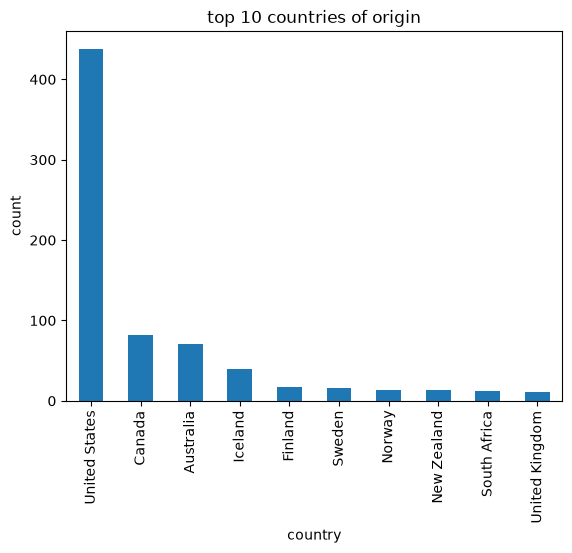

In [151]:
crossfit_df["countryOfOriginName"].value_counts().head(10).plot(kind="bar")
plt.xlabel("country")
plt.ylabel("count")
plt.title("top 10 countries of origin")
plt.show()

the USA is the most common country of origin among the available values. about 42.9% of the country values are missing and several countries appear only once

In [152]:
crossfit_df["regionName"].value_counts().head(15)

regionName
Europe                 111
North America           83
Australia               48
Central East            45
North East              44
Mid Atlantic            39
South West              38
Southern California     38
South Central           38
North West              37
South East              36
North Central           35
Northern California     32
Canada East             26
Canada West             25
Name: count, dtype: int64

In [153]:
crossfit_df["regionName"].nunique(), crossfit_df["regionName"].isna().sum()

(29, np.int64(886))

In [154]:
crossfit_df["regionName"].isna().mean()*100

np.float64(51.69194865810969)

In [156]:
region_counts = crossfit_df["regionName"].value_counts()
(region_counts == 1).sum()

np.int64(2)

In [157]:
crossfit_df["regionName"].value_counts(normalize=True).head()

regionName
Europe           0.134058
North America    0.100242
Australia        0.057971
Central East     0.054348
North East       0.053140
Name: proportion, dtype: float64

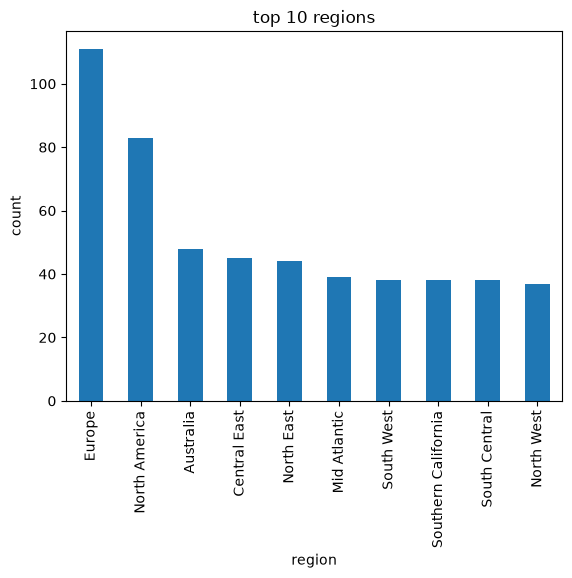

In [158]:
crossfit_df["regionName"].value_counts().head(10).plot(kind="bar")
plt.xlabel("region")
plt.ylabel("count")
plt.title("top 10 regions")
plt.show()

europ is the most common region among the available values about 51% of the region values are missing and only two regions appear once

In [ ]:
crossfit_df["affiliateName"].value_counts().head(15)

affiliateName
CrossFit Mayhem              21
CrossFit New England         11
CrossFit Reykjavík           10
CrossFit Invictus            10
Diablo CrossFit              10
CrossFit Mentality           10
Peak 360 CrossFit             9
Reebok CrossFit Frankston     9
CrossFit Hengill              9
CrossFit Oslo                 9
CrossFit Omaha                7
CrossFit Krypton              7
Champlain Valley CrossFit     7
CrossFit Fort Vancouver       7
C23 CrossFit                  7
Name: count, dtype: int64

In [160]:
crossfit_df["affiliateName"].nunique(), crossfit_df["affiliateName"].isna().sum()

(470, np.int64(802))

In [161]:
affiliate_counts = crossfit_df["affiliateName"].value_counts()
(affiliate_counts == 1).sum()


np.int64(285)

In [162]:
crossfit_df["affiliateName"].isna().mean()*100

np.float64(46.79113185530922)

In [163]:
crossfit_df.select_dtypes(include="object").columns

/var/folders/d6/jtq8yn554n9913rvpqyb38sr0000gn/T/ipykernel_41765/441948507.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  crossfit_df.select_dtypes(include="object").columns


Index(['competitorName', 'firstName', 'lastName', 'status', 'gender',
       'countryOfOriginCode', 'countryOfOriginName', 'regionName',
       'affiliateName'],
      dtype='str')

In [164]:
crossfit_df["status"].value_counts()

status
ACT    990
CUT    650
WD      58
DNF     10
DQ       6
Name: count, dtype: int64

In [165]:
crossfit_df["status"].value_counts(normalize=True)*100

status
ACT    57.759627
CUT    37.922987
WD      3.383897
DNF     0.583431
DQ      0.350058
Name: proportion, dtype: float64

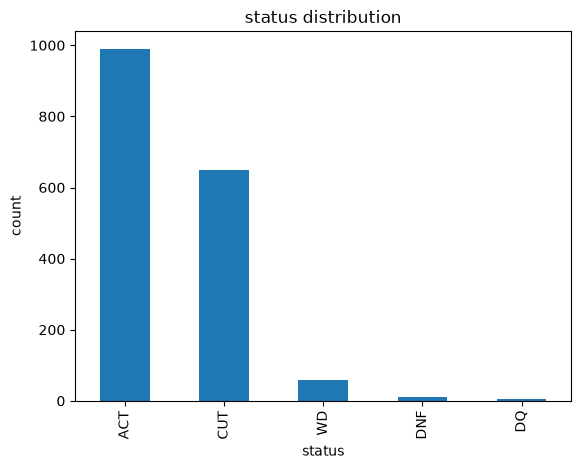

In [166]:
crossfit_df["status"].value_counts().plot(kind="bar")
plt.xlabel("status")
plt.ylabel("count")
plt.title("status distribution")
plt.show()

In [167]:
numeric_analysis = crossfit_df[["age", "overallRank", "overallScore"]].copy()
numeric_analysis = numeric_analysis[(numeric_analysis["age"]>0) & (numeric_analysis["overallRank"]>0) & (numeric_analysis["overallScore"]>0)] 
numeric_analysis.corr(method="pearson")

,age,overallRank,overallScore
age,1.000000,0.08088,-0.118686
overallRank,0.080880,1.00000,-0.701610
overallScore,-0.118686,-0.70161,1.000000


In [168]:
numeric_analysis.corr(method="spearman")

,age,overallRank,overallScore
age,1.000000,0.086373,-0.103516
overallRank,0.086373,1.000000,-0.696983
overallScore,-0.103516,-0.696983,1.000000


In [170]:
numeric_analysis.corr(method="kendall")

ModuleNotFoundError: No module named 'scipy'

In [171]:
import sys
!{sys.executable} -m pip install scipy 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 29.0 MB/s  0:00:01m0:00:0100:01

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [172]:
from scipy.stats import kendalltau

In [173]:
numeric_analysis.corr(method="kendall")

,age,overallRank,overallScore
age,1.000000,0.059731,-0.069747
overallRank,0.059731,1.000000,-0.577045
overallScore,-0.069747,-0.577045,1.000000


 #these three methods give similiar conclusions although kendall produced a slightly weaker cofficient

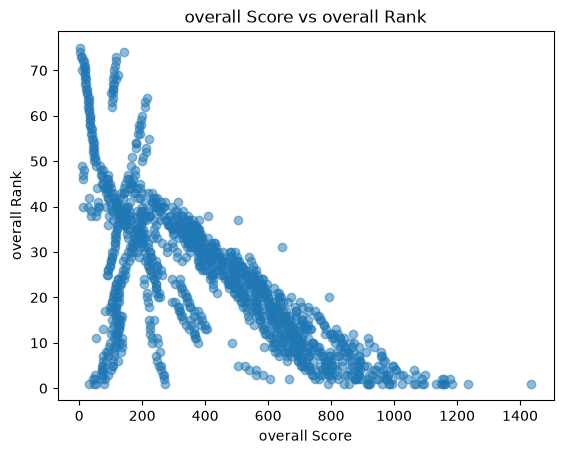

In [175]:
plt.scatter(numeric_analysis["overallScore"], numeric_analysis["overallRank"], alpha = 0.5)
plt.xlabel("overall Score")
plt.ylabel("overall Rank")
plt.title("overall Score vs overall Rank")
plt.show()

In [176]:
pd.crosstab(crossfit_df["gender"],crossfit_df["status"])

status,ACT,CUT,DNF,DQ,WD
gender,,,,,
F,442,314,5,2,30
M,548,336,5,4,28


In [180]:
from scipy.stats import chi2_contingency 
import numpy as np
table = pd.crosstab(crossfit_df["gender"], crossfit_df["status"])
chi2 = chi2_contingency (table)[0]
n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n *(min(table.shape) -1)))
cramers_v

np.float64(0.043806349438043804)

carmers v is approximately 0.0044, indicating a very weak association between gender and competition status

In [181]:
crossfit_df["age_group"] = pd.cut(crossfit_df["age"], bins=[0, 20, 30, 40, 100], labels=["<=20", "21-30", "31-40", "41+"])
pd.crosstab(crossfit_df["age_group"], crossfit_df["status"])

status,ACT,CUT,DNF,DQ,WD
age_group,,,,,
<=20,36,20,2,0,2
21-30,704,438,4,5,30
31-40,187,162,4,1,18
41+,13,10,0,0,1


In [183]:
age_status_table=pd.crosstab(
    crossfit_df["age_group"], crossfit_df["status"]
)
chi2 = chi2_contingency(age_status_table)[0]
n = age_status_table.to_numpy().sum()
age_status_v = np.sqrt(chi2 / (n *(min(age_status_table.shape)-1)))
age_status_v

np.float64(0.06923914559524597)

<function matplotlib.pyplot.show(close=None, block=None)>

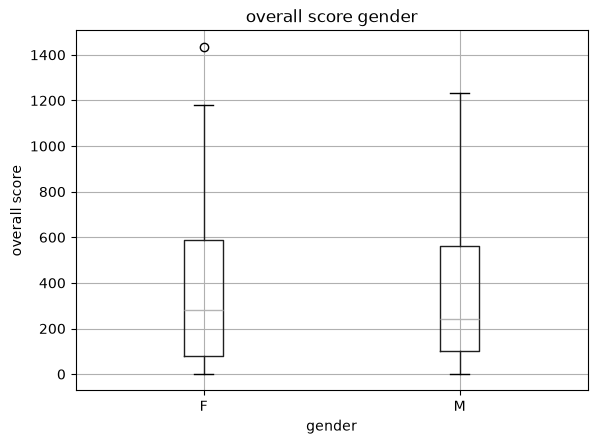

In [185]:
crossfit_df.boxplot(column="overallScore", by="gender")
plt.title("overall score gender")
plt.suptitle("")
plt.xlabel("gender")
plt.ylabel("overall score")
plt.show

#the overallscore distribution for males and females are relatively similar with no major different between the two groups

In [188]:
crossfit_df.index.is_unique, crossfit_df.index.is_monotonic_increasing

(True, True)

In [189]:
crossfit_df["competitorId"].is_unique

False

the dataframe index is unique and stored in increasing order. it is not timebased
the competitorId column is not unique so it is cannot be used as unique insex by itself

## 8. main insight and data story
1. a strong negative relationship was found between overallscore.and overallrank. competitors with higher scores generally have better (lower) rank values
2. age showed only a very weak relationship with both overallscore and overallrank this suggests that age alone does not explain competition results in this dataset.
3.gender and competition status were also only weakly associated (cremers v = 0.44) after dividing age into groups the relationship between age group and status was also very weak
an important limitation of the dataset is the large amount of missing data variables such as country and region therfore conclusions based on these variables should be interpreted carefully.
overall the analysis showed that some intuitive characterisics such as age and gender were not strongly associated with the competition outcomes while score and rank showed the clearest relationship